# 系统带练：标定、时间、规划与学习怎样接起来

配套：[工程数学](../engineering/01_math.md#worked-lessons)、[运动学](../engineering/06_kinematics.md#worked-lessons)、[感知](../engineering/09_perception.md#worked-lessons)、[AI](../engineering/10_ai.md#worked-lessons)。
这份Notebook使用同一批小数据贯穿计算、独立验证与接口检查。它不构成完整机器人系统，不发送动作。每步先预测结果，再运行；最后记录一个被主动发现的错误。


In [1]:
from pathlib import Path
import sys, math, csv, json

# Locate the course even when the kernel starts in notebooks/.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "labs" / "course_lab.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the complete trainning_materials folder.")
sys.path.insert(0, str(ROOT / "labs"))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, HTML
import ipywidgets as widgets
from course_lab import fk, ik, encode_frame, decode_frame, feedback_fresh, sphere_gap, fit_line, mse
from algorithm_lab import jacobian, numerical_ik, astar, trapezoid, kalman_step, pid_demo
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})
print("Python:", sys.executable)
print("Course:", ROOT.name)


Python: D:\code_agent\trainning_materials\.venv\Scripts\python.exe
Course: trainning_materials


In [2]:
from workshop_lab import calibration_report, interpolate_position
from engineering_lab import sample_segment, episode_overlap


## 1. 标定先拟合，再用未见点检查
三个训练点描述y=2x+1。先预测a、b和两个独立点；再把独立测量改动，观察训练关系完全正确并不使实际测量误差自动为0。


In [3]:
train = [(0., 1.), (1., 3.), (2., 5.)]
exact_report = calibration_report(train, [(3., 7.), (4., 9.)])
noisy_report = calibration_report(train, [(3., 7.2), (4., 8.8)])
print("exact:", exact_report)
print("independent perturbed measurements:", noisy_report)
assert exact_report["gain"] == 2 and exact_report["bias"] == 1
assert abs(noisy_report["heldout_rmse"] - .2) < 1e-12
try:
    calibration_report([(1., 2.), (1., 3.)], [(2., 4.)])
except ValueError as error:
    print("degenerate data rejected:", error)


exact: {'gain': 2.0, 'bias': 1.0, 'heldout': [{'input': 3.0, 'measured': 7.0, 'predicted': 7.0, 'residual': 0.0}, {'input': 4.0, 'measured': 9.0, 'predicted': 9.0, 'residual': 0.0}], 'heldout_rmse': 0.0}
independent perturbed measurements: {'gain': 2.0, 'bias': 1.0, 'heldout': [{'input': 3.0, 'measured': 7.2, 'predicted': 7.0, 'residual': -0.20000000000000018}, {'input': 4.0, 'measured': 8.8, 'predicted': 9.0, 'residual': 0.1999999999999993}], 'heldout_rmse': 0.19999999999999973}
degenerate data rejected: Unidentifiable gain: training inputs do not vary enough


## 2. 从梯度更新走向同一个解
损失为平均平方误差，初始a=b=0。先手算梯度−26/3和−6，以及第一次更新a=.8666667、b=.6。训练曲线上的每个点对应更新前的损失，打印参数时注明迭代数。


{'step': 0, 'a': 0.0, 'b': 0.0, 'loss': 11.666666666666666}
{'step': 1, 'a': 0.8666666666666667, 'b': 0.6000000000000001, 'loss': 3.2074074074074073}
{'step': 300, 'a': 1.9999999931829917, 'b': 1.0000000094580936, 'loss': 3.7956399629128157e-17}


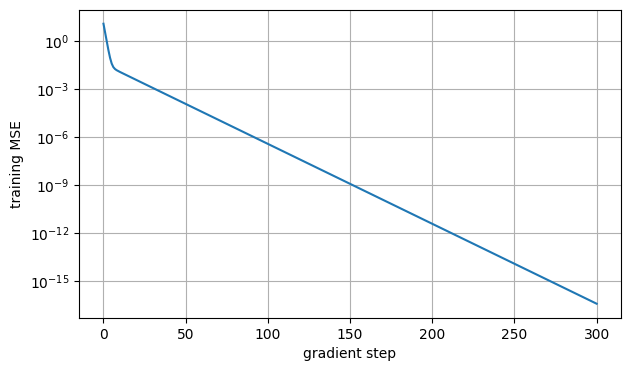

In [4]:
x = np.array([p[0] for p in train]); y = np.array([p[1] for p in train])
a = b = 0.; history = []
for step in range(301):
    residual = a*x+b-y
    history.append({"step": step, "a": a, "b": b, "loss": float(np.mean(residual**2))})
    if step < 300:
        da = float(2*np.mean(residual*x)); db = float(2*np.mean(residual))
        a -= .1*da; b -= .1*db
for index in (0, 1, 300):
    print(history[index])
assert abs(history[1]["a"] - 26/30) < 1e-12
assert abs(history[1]["b"] - .6) < 1e-12
assert history[-1]["loss"] < 1e-8
plt.semilogy([r["step"] for r in history], [r["loss"] for r in history])
plt.xlabel("gradient step"); plt.ylabel("training MSE"); plt.show()


## 3. 用旋转变化辨认TCP
平面固定点实验：R0=I,t0=(.4,.2)，R1=90°,t1=(.5,.1)。未知向量为[px,py,cx,cy]，方程[R,-I]unknown=-t。先按正文手算(.1,0,.5,.2)，再用矩阵求解。第三个姿态只作独立验证。


In [5]:
rotations = [np.eye(2), np.array([[0., -1.], [1., 0.]])]
translations = [np.array([.4, .2]), np.array([.5, .1])]
A = np.vstack([np.hstack([r, -np.eye(2)]) for r in rotations])
rhs = np.concatenate([-t for t in translations])
solution, residuals, rank, singular_values = np.linalg.lstsq(A, rhs, rcond=None)
tcp, fixed = solution[:2], solution[2:]
check = -np.eye(2) @ tcp + np.array([.6, .2])
print("TCP:", tcp, "fixed point:", fixed, "rank:", rank)
print("held-out fixed point:", check)
assert np.allclose(solution, [.1, 0., .5, .2])
assert np.allclose(check, fixed)
A_degenerate = np.vstack([np.hstack([np.eye(2), -np.eye(2)])]*2)
print("same-rotation rank:", np.linalg.matrix_rank(A_degenerate))
assert np.linalg.matrix_rank(A_degenerate) < 4


TCP: [ 1.00000000e-01 -1.11022302e-16] fixed point: [0.5 0.2] rank: 4
held-out fixed point: [0.5 0.2]
same-rotation rank: 2


## 4. 图像时刻必须落在姿态缓存的有效区间
两个位置样本1.000s/.20m和1.020s/.24m，图像1.005s的位置应为.21m。最新值.24m会多出.03m。没有包围样本时，本函数拒绝外推。


In [6]:
samples = [(1., .20), (1.020, .24)]
at_capture = interpolate_position(samples, 1.005, .03)
print("at capture:", at_capture, "latest-value error:", samples[-1][1]-at_capture)
assert abs(at_capture - .21) < 1e-12
for label, data, capture, gap in [
    ("outside history", samples, 1.030, .03),
    ("missing interval", [(1., .2), (1.2, .24)], 1.005, .03),
]:
    try:
        interpolate_position(data, capture, gap)
    except ValueError as error:
        print(label, "rejected:", error)
    else:
        raise AssertionError("Invalid interpolation accepted")


at capture: 0.2099999999999998 latest-value error: 0.030000000000000193
outside history rejected: No bracket: extrapolation is not allowed
missing interval rejected: Interpolation bracket is too wide


## 5. 路径比终点多一个需要检查的对象
先运行3×3绕墙A*，手算代价6；再用一维薄障碍展示：端点和中点都有效仍可能穿越障碍。增加分辨率只对本例有效，不能声称普遍连续安全。


In [7]:
route = astar(3, 3, {(1, 0), (1, 1)}, (0, 0), (2, 0))
print("A*:", route)
assert route["success"] and route["cost"] == 6
coarse = sample_segment(0., 1., (.24, .26), 2)
refined = sample_segment(0., 1., (.24, .26), 4)
print("coarse:", coarse)
print("refined:", refined)
assert coarse["sampled_valid"] and not refined["sampled_valid"]


A*: {'success': True, 'path': [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0)], 'cost': 6, 'expanded': [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0)]}
coarse: {'samples': [0.0, 0.5, 1.0], 'collisions': [], 'sampled_valid': True, 'scope': 'discrete samples, not continuous collision certification'}
refined: {'samples': [0.0, 0.25, 0.5, 0.75, 1.0], 'collisions': [0.25], 'sampled_valid': False, 'scope': 'discrete samples, not continuous collision certification'}


## 6. 拆分检查和执行门禁都是接口工作
先检查episode交集，再检查场景/日期与预处理。执行例只演示条件组合：新鲜反馈、匹配的场景版本、有限目标必须同时成立；实际系统还需设备模式、限值、路径等条件。


In [8]:
print("leaked episodes:", episode_overlap(["A", "B"], ["A", "C"]))
print("disjoint episodes:", episode_overlap(["A", "B"], ["C", "D"]))
cases = [
    {"name": "matching", "fresh": True, "planned_scene": 4, "current_scene": 4, "target": .2},
    {"name": "old scene", "fresh": True, "planned_scene": 4, "current_scene": 5, "target": .2},
    {"name": "old feedback", "fresh": False, "planned_scene": 4, "current_scene": 4, "target": .2},
    {"name": "invalid target", "fresh": True, "planned_scene": 4, "current_scene": 4, "target": float("nan")},
]
for case in cases:
    allowed = (case["fresh"] and case["planned_scene"] == case["current_scene"]
               and math.isfinite(case["target"]))
    print(case["name"], "teaching gate:", allowed)


leaked episodes: ['A']
disjoint episodes: []
matching teaching gate: True
old scene teaching gate: False
old feedback teaching gate: False
invalid target teaching gate: False


## 7. 提交一份跨层问题记录
任选：训练数据退化、TCP姿态不够、图像时间过期、薄障碍漏检或场景版本改变。写原始输入、预期、实际结果、错误发生在哪层及修正。不要把所有错误统一归为“算法不好”。

参考判断：退化是参数可辨识性问题；时间错配会产生空间误差；规划结果绑定原场景；没有episode交集只证明这一项检查通过。


In [9]:
out = ROOT / "outputs" / "workshop_system.json"
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps({"scope": "offline worked examples", "calibration": noisy_report,
                          "gradient_final": history[-1], "tcp": solution.tolist(),
                          "image_time_position": at_capture, "astar_cost": route["cost"]},
                         indent=2) + "\n", encoding="utf-8")
print("Saved:", out)


Saved: D:\code_agent\trainning_materials\outputs\workshop_system.json
